In [12]:
import pandas as pd

df = pd.read_csv('/content/Real_estate_job_clean - V3.csv.csv')

print(df.isnull().sum())

Date                 0
Year                 0
Locality             0
Estimated Value      0
Sale Price           0
Property             0
Residential          0
num_rooms            0
num_bathrooms        0
carpet_area          0
property_tax_rate    0
Face                 0
dtype: int64


In [13]:
locality_analysis = df.groupby('Locality')['Sale Price'].mean().sort_values(ascending=False)

pd.options.display.float_format = '{:,.2f}'.format

print(locality_analysis)

Locality
Greenwich       2,254,461.95
Fairfield         732,616.58
Stamford          653,734.47
Norwalk           584,494.33
West Hartford     343,321.90
Bridgeport        175,241.10
Waterbury         107,694.18
Name: Sale Price, dtype: float64


In [14]:
df['Price_Per_SqFt'] = df['Sale Price'] / df['carpet_area']

sqft_analysis = df.groupby('Locality')['Price_Per_SqFt'].mean().sort_values(ascending=False)

print(sqft_analysis.head())

Locality
Greenwich       2,239.74
Fairfield         732.47
Stamford          633.30
Norwalk           573.71
West Hartford     338.91
Name: Price_Per_SqFt, dtype: float64


In [15]:
sqft_summary = df.groupby('Locality')['Price_Per_SqFt'].mean().sort_values(ascending=False)

print("--- MOST EXPENSIVE (TOP 5) ---")
print(sqft_summary.head())

print("\n--- MOST AFFORDABLE (BOTTOM 5) ---")
print(sqft_summary.tail())

--- MOST EXPENSIVE (TOP 5) ---
Locality
Greenwich       2,239.74
Fairfield         732.47
Stamford          633.30
Norwalk           573.71
West Hartford     338.91
Name: Price_Per_SqFt, dtype: float64

--- MOST AFFORDABLE (BOTTOM 5) ---
Locality
Stamford        633.30
Norwalk         573.71
West Hartford   338.91
Bridgeport      149.67
Waterbury        96.89
Name: Price_Per_SqFt, dtype: float64


In [16]:
df['Down_Payment_Credit'] = df['Sale Price'] * 0.050

credit_analysis = df.groupby('Locality')['Down_Payment_Credit'].mean()

print("--- AVERAGE TENANT CREDIT BY LOCALITY ---")
print(f"Greenwich: ${credit_analysis['Greenwich']:,.2f}")
print(f"Waterbury: ${credit_analysis['Waterbury']:,.2f}")

--- AVERAGE TENANT CREDIT BY LOCALITY ---
Greenwich: $112,723.10
Waterbury: $5,384.71


In [17]:
df['Price_Per_Room'] = df['Sale Price'] / df['num_rooms']

room_value = df.groupby('Locality')['Price_Per_Room'].mean().sort_values()

print("--- TOP 5 BEST VALUE (Lowest Price Per Room) ---")
print(room_value.head())

--- TOP 5 BEST VALUE (Lowest Price Per Room) ---
Locality
Waterbury        32,297.19
Bridgeport       49,988.75
West Hartford   112,689.05
Norwalk         191,359.39
Stamford        211,044.42
Name: Price_Per_Room, dtype: float64


In [18]:
df.to_csv('Real_estate_case_pyt.csv', index=False)

print("Project Complete! Your analyzed data is saved as Real_estate_case_pyt.csv.")

Project Complete! Your analyzed data is saved as Real_estate_case_pyt.csv.


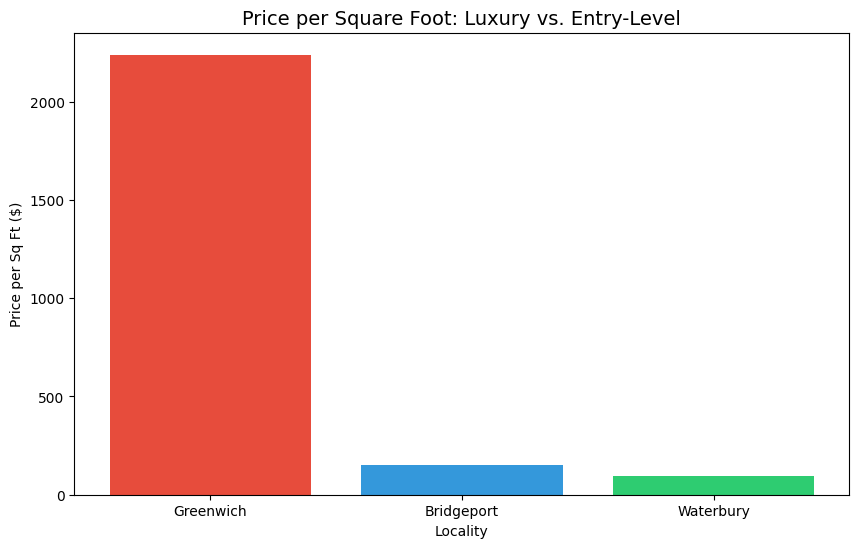

In [19]:
import matplotlib.pyplot as plt

cities = ['Greenwich', 'Bridgeport', 'Waterbury']
prices = [df[df['Locality'] == city]['Price_Per_SqFt'].mean() for city in cities]

plt.figure(figsize=(10, 6))
plt.bar(cities, prices, color=['#e74c3c', '#3498db', '#2ecc71'])

plt.title('Price per Square Foot: Luxury vs. Entry-Level', fontsize=14)
plt.ylabel('Price per Sq Ft ($)')
plt.xlabel('Locality')

plt.show()